# Non-reverse-engineerability study on IEEE-118

When the synthesiser runs in reference mode it reads statistics from a real
network. If that network is confidential, the question is what an observer of
the published synthetic grids can infer about it. The perturbation layer
(`powergrid_synth.privacy`) displaces reference-derived parameters with
calibrated noise; this notebook measures how much of the reference still
reaches an adversary.

It reproduces the study behind `scripts/measure_topology_recovery.py` on the
public IEEE 118-bus case: the same perturbation configuration, the same
adversary estimators and the same recovery figure. With the default settings
the numbers it produces are identical to the script's output.

Expected runtime: about two minutes (four batches of thirty grids).

## Threat model

The adversary holds the synthetic grids **and** the source code, which is
open; no protection depends on the method staying secret.

- A **single-sample adversary** sees one grid. The synthesiser's own
  randomness already makes one grid a poor estimate of the reference.
- A **pooling adversary** sees many grids generated from the same reference
  and combines them. Pooling averages out the synthesiser's randomness, so any
  characteristic that is fixed across runs becomes estimable.

Perturbation is meant to set a floor that pooling cannot cross. That works
because the noise is drawn **once per batch**: every grid in a published batch
carries the same displacement, so averaging within the batch converges to the
*displaced* value, not to the reference. The study therefore fixes one noise
seed per batch and varies only the synthesiser seed from grid to grid.

The same reasoning is why a data owner should publish one batch per reference
network: independent noise draws across several batches would average out.
See `docs/theory/perturbation.rst` for the full discussion.

Three topology parameters are perturbed together, as a single release would:

| Parameter | What it is | Adversary's estimator |
|---|---|---|
| `node_count` | buses per voltage level | pooled mean with a 95 % confidence interval |
| `degrees_by_level` | connection-count pattern | Kolmogorov–Smirnov distance between the pooled and the reference degree distribution |
| `diameters_by_level` | network span per level, in hops | span realised in the generated grids, against their run-to-run spread |

In [ ]:
import contextlib
import io
import statistics
import tempfile

import matplotlib.pyplot as plt
import networkx as nx
import pandapower.networks as pandapower_networks
import pandas as pd

from powergrid_synth.core.data_format_converter import pandapower_to_nx
from powergrid_synth.core.input_extractor import extract_topology_params_from_graph
from powergrid_synth.privacy.recovery import recover_degree_dist_full, recover_node_count
from powergrid_synth.transmission.synthesize import synthesize

## Study settings

Every setting lives in this cell. The defaults match
`scripts/measure_topology_recovery.py`; change them to explore, but keep in
mind that the parity with the script only holds for the defaults.

In [ ]:
# Built-in pandapower case used as the confidential reference.
REFERENCE_CASE = "case118"

# Grids per batch, i.e. the size of the adversary's pool.
N_GRIDS = 30

# Perturbation strengths to compare; 0.0 is the unprotected baseline.
STRENGTHS = (0.0, 0.5, 1.0, 2.0)

# Noise seed shared by every grid in a batch, so the displacement is identical
# across the batch and pooling cannot average it away.
BATCH_SEED = 4242

# The parameters perturbed together, as one published release would.
PERTURBED_PARAMETERS = ("node_count", "degrees_by_level", "diameters_by_level")

# Synthesiser seeds: one per grid, varied within a batch.
GRID_SEEDS = range(N_GRIDS)

## The reference grid

The reference is loaded from pandapower and passed through the same extractor
the synthesiser uses in reference mode. The values below are what the
adversary is trying to recover.

In [ ]:
reference_graph = pandapower_to_nx(getattr(pandapower_networks, REFERENCE_CASE)())
true_params = extract_topology_params_from_graph(reference_graph)

true_node_counts = [len(level_degrees) for level_degrees in true_params["degrees_by_level"]]
true_spans = [int(span) for span in true_params["diameters_by_level"]]

pd.DataFrame(
    {"true buses": true_node_counts, "true span [hops]": true_spans},
    index=pd.Index(range(len(true_node_counts)), name="voltage level"),
)

Extracting topology parameters...

,true buses,true span [hops]
voltage level,,
0,11,7
1,2,0
2,105,17


## Generating the adversary's pools

`build_config` returns the perturbation configuration for one batch. Strength
zero means no configuration at all, which is exactly the unprotected pipeline.
`generate_pool` then synthesises one batch: the noise seed is fixed, the
synthesiser seed runs over `GRID_SEEDS`.

In [ ]:
def build_config(strength, batch_seed):
    """Perturbation configuration for one batch, or ``None`` for the baseline.

    Args:
        strength: Perturbation strength; zero means no perturbation at all.
        batch_seed: Noise seed shared by every grid in the batch.

    Returns:
        A configuration mapping, or ``None`` when *strength* is zero.
    """
    if strength <= 0.0:
        return None
    return {
        "strength": strength,
        "seed": batch_seed,
        "parameters": {name: {"mode": "perturb"} for name in PERTURBED_PARAMETERS},
    }


def generate_pool(reference_case, strength, n_grids, output_dir):
    """Synthesise one batch of grids from the reference.

    Args:
        reference_case: Name of the built-in reference network.
        strength: Perturbation strength for the batch.
        n_grids: Pool size.
        output_dir: Scratch directory for the exporter; nothing is exported.

    Returns:
        List of generated graphs.
    """
    config = build_config(strength, batch_seed=BATCH_SEED)
    graphs = []
    for grid_index in range(n_grids):
        # The synthesiser is chatty; the progress reported here is our own.
        with contextlib.redirect_stdout(io.StringIO()):
            graphs.append(
                synthesize(
                    mode="reference",
                    reference_case=reference_case,
                    seed=grid_index,
                    perturbation_config=config,
                    output_dir=output_dir,
                    output_name=f"pool_{strength}_{grid_index}",
                    export_formats=(),
                )
            )
    return graphs

## The adversary's estimators

Buses per level and the degree distribution use the estimators in
`powergrid_synth.privacy.recovery`. The span needs its own measurement: it is a
*target* handed to the topology generator rather than a value written to the
output, so the adversary can only observe the span the generator actually
realised — the diameter of the largest connected component at each level.

In [ ]:
def measure_spans_by_level(graph):
    """Realised network span of each voltage level.

    Args:
        graph: Generated grid whose nodes carry ``voltage_level``.

    Returns:
        Span per level in hops, indexed by level number; ``0`` for a level with
        fewer than two buses.
    """
    nodes_by_level = {}
    for node, data in graph.nodes(data=True):
        nodes_by_level.setdefault(int(data.get("voltage_level", 0)), []).append(node)

    spans = []
    for level in range(max(nodes_by_level) + 1 if nodes_by_level else 0):
        level_subgraph = graph.subgraph(nodes_by_level.get(level, []))
        if level_subgraph.number_of_nodes() < 2:
            spans.append(0)
            continue
        largest_component = max(nx.connected_components(level_subgraph), key=len)
        spans.append(int(nx.diameter(level_subgraph.subgraph(largest_component))))
    return spans


def measure(graphs, true_params):
    """Run every adversary estimator against one pooled batch.

    Args:
        graphs: The batch of synthetic grids.
        true_params: Reference parameters from the topology extractor.

    Returns:
        Mapping of parameter name to that parameter's recovery result.
    """
    true_degrees = true_params["degrees_by_level"]
    n_levels = len(true_degrees)

    node_counts = recover_node_count(graphs, n_levels)
    for level in range(n_levels):
        node_counts[level]["true"] = len(true_degrees[level])
        node_counts[level].pop("counts", None)

    spans_per_grid = [measure_spans_by_level(graph) for graph in graphs]
    spans = {}
    for level in range(n_levels):
        values = [row[level] for row in spans_per_grid if level < len(row)]
        spans[level] = {
            "mean": statistics.fmean(values),
            "stdev": statistics.stdev(values) if len(values) > 1 else 0.0,
            "true": int(true_params["diameters_by_level"][level]),
        }

    return {
        "node_count": node_counts,
        "degrees_by_level": {"ks_distance": recover_degree_dist_full(graphs, true_degrees)},
        "diameters_by_level": spans,
    }

## Running the study

One batch per strength, each measured as soon as it is generated. The
synthesiser needs an output directory even when nothing is exported, so a
temporary one is used and removed afterwards.

In [ ]:
results = {
    "reference_case": REFERENCE_CASE,
    "n_grids": N_GRIDS,
    "perturbed_parameters": list(PERTURBED_PARAMETERS),
    "true_node_counts": true_node_counts,
    "true_spans": true_spans,
    "by_strength": {},
}

with tempfile.TemporaryDirectory() as scratch_dir:
    for strength in STRENGTHS:
        graphs = generate_pool(REFERENCE_CASE, strength, N_GRIDS, scratch_dir)
        results["by_strength"][str(strength)] = measure(graphs, true_params)
        print(f"strength {strength}: {len(graphs)} grids pooled and measured")

'opf' extra dependencies are not installed, some features will not be available


strength 0.0: 30 grids pooled and measured

strength 0.5: 30 grids pooled and measured

strength 1.0: 30 grids pooled and measured

strength 2.0: 30 grids pooled and measured

## Results

### Buses per voltage level

For each strength and level: the true bus count, the adversary's pooled mean
and its 95 % confidence interval, and the ratio of estimate to truth.

How to read it: a ratio of 1.0 means the adversary recovered the count
exactly. A parameter is displaced beyond what pooling can resolve when the
ratio sits away from 1.0 **and** the confidence interval excludes the true
count. Because the noise is drawn in buses, the same strength moves a small
level proportionally more than a large one.

In [ ]:
node_count_rows = []
for strength_key, block in results["by_strength"].items():
    for level, stats in block["node_count"].items():
        node_count_rows.append({
            "strength": float(strength_key),
            "level": level,
            "true": stats["true"],
            "mean": stats["mean"],
            "ci_lo": stats["ci_lo"],
            "ci_hi": stats["ci_hi"],
            "mean / true": stats["mean"] / stats["true"],
            "true inside CI": stats["ci_lo"] <= stats["true"] <= stats["ci_hi"],
        })
pd.DataFrame(node_count_rows).set_index(["strength", "level"]).round(3)

true     mean    ci_lo    ci_hi  mean / true  true inside CI
strength level                                                              
0.0      0        11   13.500   13.256   13.744        1.227           False
         1         2    1.767    1.613    1.921        0.883           False
         2       105  105.433  104.392  106.474        1.004            True
0.5      0        11   12.933   12.503   13.363        1.176           False
         1         2    3.000    3.000    3.000        1.500           False
         2       105  104.967  103.935  105.998        1.000            True
1.0      0        11   16.867   16.623   17.111        1.533           False
         1         2    2.967    2.901    3.032        1.483           False
         2       105  103.867  103.088  104.646        0.989           False
2.0      0        11   17.733   16.914   18.552        1.612           False
         1         2    4.567    4.386    4.747        2.283           False
         2       105   91.300   89.509   93.091        0.870           False

### Connection-count pattern

The Kolmogorov–Smirnov distance between the pooled degree distribution of all
grids in the batch and the reference degree distribution, all levels combined.

How to read it: the unperturbed row (strength 0) is the floor set by the
synthesiser alone — the generator never reproduces the reference distribution
exactly. Protection shows as a distance above that floor. A distance at or
below the baseline means the perturbed batch is at least as close to the
reference as an unprotected one.

In [ ]:
pd.DataFrame(
    {
        "strength": [float(key) for key in results["by_strength"]],
        "KS distance": [
            block["degrees_by_level"]["ks_distance"] for block in results["by_strength"].values()
        ],
    }
).set_index("strength").round(4)

,KS distance
strength,
0.0,0.1344
0.5,0.1191
1.0,0.1862
2.0,0.2539


### Network span

For each strength and level: the reference span, and the mean and standard
deviation of the span realised across the batch.

How to read it: the span is a target, not an output, so compare the realised
mean with the true span *in units of the run-to-run spread*. A shift that is
small against the standard deviation is not a displacement an adversary would
notice — whatever the configured strength says.

In [ ]:
span_rows = []
for strength_key, block in results["by_strength"].items():
    for level, stats in block["diameters_by_level"].items():
        span_rows.append({
            "strength": float(strength_key),
            "level": level,
            "true": stats["true"],
            "mean": stats["mean"],
            "stdev": stats["stdev"],
        })
pd.DataFrame(span_rows).set_index(["strength", "level"]).round(2)

true   mean  stdev
strength level                    
0.0      0         7   6.83   0.83
         1         0   0.00   0.00
         2        17  18.13   1.38
0.5      0         7   5.50   1.53
         1         0   1.00   0.00
         2        17  17.50   1.48
1.0      0         7   6.73   1.23
         1         0   1.00   0.00
         2        17  17.73   0.87
2.0      0         7   4.27   1.20
         1         0   2.43   0.50
         2        17  19.93   1.28

### Recovery figure

The three estimators against perturbation strength, in the layout of
`scripts/make_recovery_figure.py`. Dashed red lines mark the reference value;
the further and more consistently an estimate sits from it, the more the
parameter is protected.

- **Left:** recovered / true buses per level, with the 95 % interval as error
  bars.
- **Centre:** KS distance, with the unperturbed distance as a dotted line.
- **Right:** realised span ± one standard deviation at the level with the
  largest reference span.

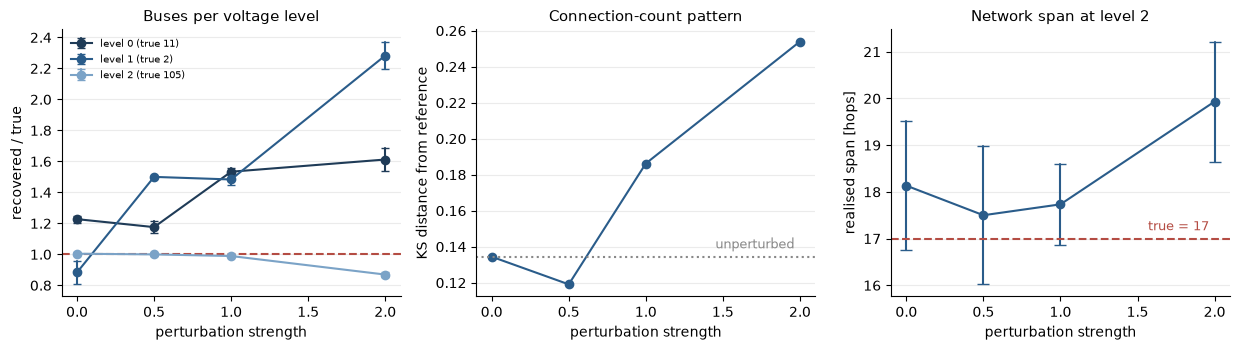

In [ ]:
TRUE_COLOUR = "#B44C43"
ESTIMATE_COLOUR = "#2A5C8A"
LEVEL_COLOURS = ("#1F3B57", "#2A5C8A", "#7BA3C7", "#B8CCE0")


def plot_recovery(results):
    """Draw the three-panel adversary-recovery figure.

    Args:
        results: Study results as produced by the loop above.

    Returns:
        The matplotlib figure.
    """
    strengths = sorted(float(key) for key in results["by_strength"])
    blocks = [results["by_strength"][str(strength)] for strength in strengths]
    figure, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))

    # Levels differ by an order of magnitude in size, so the estimate is drawn
    # relative to the truth: 1.0 means the adversary recovered it exactly.
    for level, true_count in enumerate(results["true_node_counts"]):
        ratios = [block["node_count"][level]["mean"] / true_count for block in blocks]
        errors = [
            (block["node_count"][level]["mean"] - block["node_count"][level]["ci_lo"]) / true_count
            for block in blocks
        ]
        axes[0].errorbar(
            strengths, ratios, yerr=errors, marker="o", capsize=3,
            color=LEVEL_COLOURS[level % len(LEVEL_COLOURS)],
            label=f"level {level} (true {true_count})",
        )
    axes[0].axhline(1.0, ls="--", color=TRUE_COLOUR)
    axes[0].set_title("Buses per voltage level", fontsize=10.5)
    axes[0].set_ylabel("recovered / true")
    axes[0].legend(fontsize=7.5, frameon=False)

    ks_values = [block["degrees_by_level"]["ks_distance"] for block in blocks]
    axes[1].plot(strengths, ks_values, marker="o", color=ESTIMATE_COLOUR)
    axes[1].axhline(ks_values[0], ls=":", color="#888888")
    axes[1].annotate("unperturbed", (strengths[-1], ks_values[0]),
                     textcoords="offset points", xytext=(-4, 6),
                     ha="right", color="#888888", fontsize=9)
    axes[1].set_title("Connection-count pattern", fontsize=10.5)
    axes[1].set_ylabel("KS distance from reference")

    widest_level = max(range(len(results["true_spans"])), key=lambda level: results["true_spans"][level])
    span_means = [block["diameters_by_level"][widest_level]["mean"] for block in blocks]
    span_errors = [block["diameters_by_level"][widest_level]["stdev"] for block in blocks]
    true_span = results["true_spans"][widest_level]
    axes[2].errorbar(strengths, span_means, yerr=span_errors, marker="o", capsize=4,
                     color=ESTIMATE_COLOUR)
    axes[2].axhline(true_span, ls="--", color=TRUE_COLOUR)
    axes[2].annotate(f"true = {true_span}", (strengths[-1], true_span),
                     textcoords="offset points", xytext=(-4, 6),
                     ha="right", color=TRUE_COLOUR, fontsize=9)
    axes[2].set_title(f"Network span at level {widest_level}", fontsize=10.5)
    axes[2].set_ylabel("realised span [hops]")

    for axis in axes:
        axis.set_xlabel("perturbation strength")
        axis.spines[["top", "right"]].set_visible(False)
        axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    return figure


plot_recovery(results)
plt.show()

## Notes on the perturbation methodology

- **These results describe this generator, this reference and these seeds.**
  Re-run the study on your own reference network before relying on a
  configuration; do not carry numbers over from IEEE-118. Choose the perturbation strength according to your needs.
- **A single draw is not a guarantee.** Perturbation displaces the expectation
  across hypothetical releases. The one batch you publish can land towards the
  reference as easily as away from it; changing `BATCH_SEED` shows a different
  draw.
- **No formal privacy guarantee is claimed.** Protection is evidenced by
  measurement, not by a theorem.

Further reading:

- `docs/theory/perturbation.rst` — threat model, noise mechanism, guarantees
  and limits
- `scripts/measure_topology_recovery.py` — the command-line version of this
  study
- `powergrid_synth.privacy.recovery` — the estimators, callable on any pool of
  generated graphs